### Multinomial

Demonstrate and analyze the Maximum Likelihood Estimators (MLEs) for the Multinomial Distribution. This will involve the PMF and MLEs, generating synthetic data, visualizing likelihood and log-likelihood functions (for the binomial case); performing Monte Carlo simulations to observe the distribution of estimated parameters; comparing empirical and theoretical asymptotic variances of these estimators; visualizing these comparisons; and summarizing the findings.

#### Multinomial Distribution and MLEs

The **Multinomial Distribution** is a generalization of the Binomial Distribution. While the Binomial Distribution models the number of successes in a fixed number of independent Bernoulli trials (with only two possible outcomes), the Multinomial Distribution models the counts for each of $k$ possible outcomes in a fixed number of independent trials.

The Multinomial Distribution is defined by two parameters:
1.  **Number of trials ($n$)**: The total number of independent experiments or trials performed.
2.  **Probability vector (${p}$)**: A vector of probabilities for each of the $k$ possible outcomes, ${p} = [p_1, p_2, \ldots, p_k]$, where each $p_i \ge 0$ and the sum of all probabilities is equal to 1 (i.e., $\sum_{i=1}^k p_i = 1$).

#### Probability Mass Function (PMF)

For an outcome $\boldsymbol{x} = [x_1, x_2, \ldots, x_k]$, where $x_i$ is the count of occurrences for category $i$, and the sum of these counts equals the total number of trials (i.e., $\sum_{i=1}^k x_i = n$), the PMF of the Multinomial Distribution is given by:
- $P(X_1=x_1, \ldots, X_k=x_k) = \frac{n!}{x_1! x_2! \ldots x_k!} p_1^{x_1} p_2^{x_2} \ldots p_k^{x_k}$

#### Maximum Likelihood Estimators (MLEs) for Probabilities

Given a set of observations from a Multinomial Distribution, the MLEs for the probability parameters $p_i$ are simply the sample proportions for each category. For each category $i$, the MLE $\hat{p}_i$ is calculated as
- $\hat{p}_i = \frac{x_i}{n}$, where $x_i$ is the observed count for category $i$; $n$ is the total number of trials (or sum of all observed counts, $n = \sum_{j=1}^k x_j$).

These estimators are intuitive, the best estimate for the probability of an outcome is the frequency with which that outcome was observed in the data.

Generate Synthetic Data for Multinomial Distribution using known true parameters for the probabilities.


In [1]:
import numpy as np

# Define the true parameters for the Multinomial distribution
# The total number of trials for each observation
n_trials = 100

# A list or NumPy array representing the true probabilities for each category
true_probs = np.array([0.2, 0.3, 0.5]) # Ensure these sum to 1

# The number of independent observations or samples to generate
num_observations = 1000

# Generate the synthetic data using np.random.multinomial
# size specifies the number of independent draws, each being a multinomial exp.
multinomial_data = np.random.multinomial(n_trials, true_probs, size=num_observations)

# the n_trials, true_probs, and the shape of the generated multinomial_data
print(f"Number of trials per observation (n_trials): {n_trials} \n"
f"True probabilities for each category (true_probs): {true_probs} \m"
f"Number of observations generated (num_observations): {num_observations} \n"
f"Shape of the generated multinomial_data: {multinomial_data.shape}")

Number of trials per observation (n_trials): 100 
True probabilities for each category (true_probs): [0.2 0.3 0.5] \mNumber of observations generated (num_observations): 1000 
Shape of the generated multinomial_data: (1000, 3)


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_359/1428828393.py:19: SyntaxWarning: invalid escape sequence '\m'
  f"True probabilities for each category (true_probs): {true_probs} \m"


Visualize the likelihood and log-likelihood functions for a Binomial distribution (a special case of Multinomial with two categories) by varying one probability parameter while keeping the number of trials constant. This illustrates how the MLE maximizes these functions.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Define the true parameters for a Binomial distribution
n_trials_binomial = 20  # Number of trials per observation
true_p_binomial = 0.3   # True probability of success
num_observations_binomial = 500 # Number of independent binomial experiments

# Generate synthetic data for this Binomial distribution
np.random.seed(42) # for reproducibility
binomial_data = np.random.binomial(n_trials_binomial, true_p_binomial, num_observations_binomial)

print(f"Number of trials per binomial observation (n_trials_binomial): {n_trials_binomial} \n"
f"True probability of success (true_p_binomial): {true_p_binomial} \n"
f"Number of binomial observations generated (num_observations_binomial): {num_observations_binomial} \n"
f"Shape of the generated binomial_data: {binomial_data.shape} \n"
f"First 5 values of binomial_data: {binomial_data[:5]}")

# Create an array of candidate_ps (possible probability values)
candidate_ps = np.linspace(0.01, 0.99, 100) # 100 candidate probs 0.01-0.99

print(f"\nNumber of candidate probabilities: {len(candidate_ps)}")

Number of trials per binomial observation (n_trials_binomial): 20 
True probability of success (true_p_binomial): 0.3 
Number of binomial observations generated (num_observations_binomial): 500 
Shape of the generated binomial_data: (500,) 
First 5 values of binomial_data: [5 9 7 6 4]

Number of candidate probabilities: 100


Implement functions to calculate the likelihood and log-likelihood for the Binomial data given a candidate probability $p$, as well as calculate these values for each $candidate_p$.

In [3]:
from scipy.stats import binom # Already imported, but good for context

# Implement a function to calculate the likelihood for the Binomial data
def calculate_binomial_likelihood(data, n, p):
    # Calculate PMF for each data point given the candidate probability p
    pmfs = binom.pmf(data, n, p)
    # The likelihood is the product of these PMFs. Use log-sum-exp trick for stability.
    # For visualization, we'll calculate the actual likelihood by exponentiating the sum of log-pmfs.
    log_likelihood_sum = np.sum(binom.logpmf(data, n, p))
    likelihood = np.exp(log_likelihood_sum)
    return likelihood

# Implement a function to calculate the log-likelihood for the Binomial data
def calculate_binomial_log_likelihood(data, n, p):
    # Calculate the log PMF for each data point
    log_pmfs = binom.logpmf(data, n, p)
    # The log-likelihood is the sum of these log PMFs
    log_likelihood = np.sum(log_pmfs)
    return log_likelihood

# Calculate the likelihood and log-likelihood for each candidate_p value
likelihoods_binomial = [calculate_binomial_likelihood(binomial_data, n_trials_binomial, p) for p in candidate_ps]
log_likelihoods_binomial = [calculate_binomial_log_likelihood(binomial_data, n_trials_binomial, p) for p in candidate_ps]

# Convert to numpy arrays for easier plotting
likelihoods_binomial = np.array(likelihoods_binomial)
log_likelihoods_binomial = np.array(log_likelihoods_binomial)

print(f"Calculated {len(likelihoods_binomial)} binomial likelihood values. \n"
f"Calculated {len(log_likelihoods_binomial)} binomial log-likelihood values.")

Calculated 100 binomial likelihood values. 
Calculated 100 binomial log-likelihood values.


Calculate the MLE for 'p' from the binomial data, and subplot the likelihood and log-likelihood functions. Add vertical lines for the true 'p' and the MLE 'p' to each plot for comparison, along with appropriate labels, titles, and legends to fulfill the subtask requirements.



True probability (true_p_binomial): 0.3 
Estimated MLE probability (estimated_p_mle_binomial): 0.2999


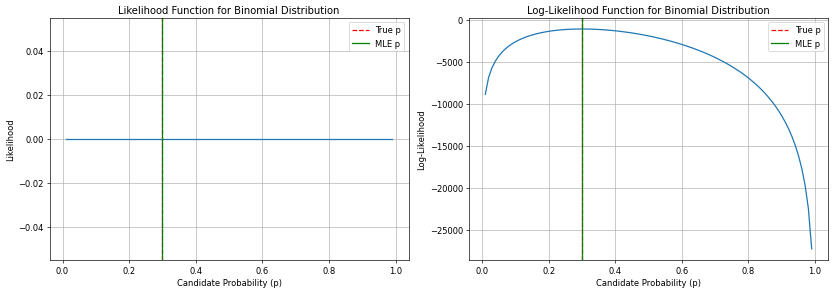

In [4]:
import matplotlib.pyplot as plt

# Calculate the MLE for p
# For a Binomial distribution, the MLE of p is sum(successes) / sum(trials)
estimated_p_mle_binomial = np.sum(binomial_data) / (num_observations_binomial * n_trials_binomial)

print(f"True probability (true_p_binomial): {true_p_binomial} \n"
f"Estimated MLE probability (estimated_p_mle_binomial): {estimated_p_mle_binomial:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

# Likelihood Function
axes[0].plot(candidate_ps, likelihoods_binomial)
axes[0].set_title('Likelihood Function for Binomial Distribution')
axes[0].set_xlabel('Candidate Probability (p)')
axes[0].set_ylabel('Likelihood')
axes[0].axvline(x=true_p_binomial, color='r', linestyle='--', label='True p')
axes[0].axvline(x=estimated_p_mle_binomial, color='g', linestyle='-', label='MLE p')
axes[0].legend() ; axes[0].grid(True)

# Log-Likelihood Function
axes[1].plot(candidate_ps, log_likelihoods_binomial)
axes[1].set_title('Log-Likelihood Function for Binomial Distribution')
axes[1].set_xlabel('Candidate Probability (p)')
axes[1].set_ylabel('Log-Likelihood')
axes[1].axvline(x=true_p_binomial, color='r', linestyle='--', label='True p')
axes[1].axvline(x=estimated_p_mle_binomial, color='g', linestyle='-', label='MLE p')
axes[1].legend() ; axes[1].grid(True)

plt.tight_layout() ; plt.show()


#### Monte Carlo Simulation for MLE of Multinomial Parameters

Perform Monte Carlo simulations by repeatedly generating data from a Multinomial distribution and calculating the MLEs for the probability parameters in each simulation. This will allow us to observe the distribution of these estimated parameters.

In [5]:
import numpy as np

# Define the number of Monte Carlo simulations and sample size per simulation
num_simulations_mle = 1000 # Number of times to repeat the data generation and estimation
num_observations_mle_sim = 500 # Number of independent observations for each simulation

# Reuse previously defined n_trials and true_probs
# n_trials = 100, true_probs = np.array([0.2, 0.3, 0.5])

# Ensure n_trials and true_probs are from above, else define them for robustness
if 'n_trials' not in globals():
    n_trials = 100
if 'true_probs' not in globals():
    true_probs = np.array([0.2, 0.3, 0.5])

k_categories = len(true_probs)

# Initialize empty list to store the estimated prob vectors for each simulation
estimated_probs_mle = []

# Loop through the specified number of simulations
for _ in range(num_simulations_mle):
    # a. Generate num_obs_mle_sim new data points - a Multinomial distribution
    # Each row in 'simulated_data' represents counts for a single multinomial experiment
    simulated_data = np.random.multinomial(n_trials, true_probs, size=num_observations_mle_sim)
    # b. Calculate the MLE for the probability vector for this simulated dataset
    # Sum counts for each category across all observations
    total_counts_per_category = np.sum(simulated_data, axis=0)
    # Total number of trials across all observations
    total_trials_sim = num_observations_mle_sim * n_trials
    # MLE for probabilities is sample proportion
    mle_probs = total_counts_per_category / total_trials_sim
    # c. Append this estimated probability vector to the list
    estimated_probs_mle.append(mle_probs)

# Convert the list of estimated probabilities into a NumPy array
estimated_probs_mle = np.array(estimated_probs_mle)

# The number of simulations, the number of observations per simulation,
# and the shape of the resulting NumPy array of estimated probabilities.
print(f"Number of Monte Carlo simulations: {num_simulations_mle} \n"
f"# of independent observations per simulation: {num_observations_mle_sim} \n"
f"Shape of estimated_probs_mle array: {estimated_probs_mle.shape}")

Number of Monte Carlo simulations: 1000 
# of independent observations per simulation: 500 
Shape of estimated_probs_mle array: (1000, 3)


#### Distribution of Estimated Multinomial Parameters

Visualize the distribution of the estimated probability parameters from the Monte Carlo simulations using appropriate plots (e.g., KDE plots or histograms) for each parameter dimension.


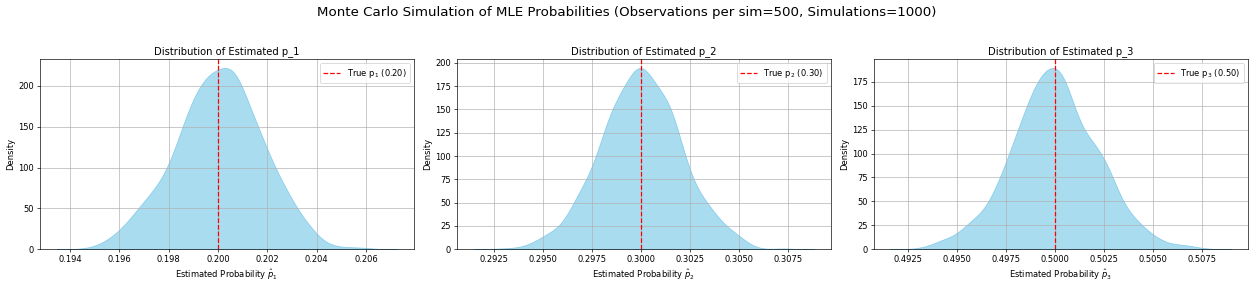

Visualization of the distribution of estimated probabilities completed.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate number of rows and columns for subplots
n_cols = k_categories # Set number of columns to k_categories
n_rows = 1 # Set number of rows to 1

# A fig. with subplots (one for each category's estimated prob. distribution).
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), dpi=60)

# Flatten the axes array for easy iteration if it's a 2D array
if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
# Ensure axes is an array even if k_categories is 1
if k_categories == 1:
    axes = [axes]

# For each category, plot a KDE of the estimated probabilities
for i in range(k_categories):
    sns.kdeplot(estimated_probs_mle[:, i], ax=axes[i], fill=True, color='skyblue', alpha=0.7)

    # Add a vertical line for the true probability of that dimension.
    axes[i].axvline(x=true_probs[i], color='red', linestyle='--', label=rf'True p$_{i+1}$ ({true_probs[i]:.2f})')

    # Add appropriate titles, x-labels, and y-labels to each subplot
    axes[i].set_title(f'Distribution of Estimated p_{i+1}')
    axes[i].set_xlabel(rf'Estimated Probability $\hat{{p}}_{i+1}$ ')
    axes[i].set_ylabel('Density')
    axes[i].legend() ; axes[i].grid(True)

# Hide any unused subplots
for j in range(k_categories, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Monte Carlo Simulation of MLE Probabilities (Observations per sim={num_observations_mle_sim}, Simulations={num_simulations_mle})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

print("Visualization of the distribution of estimated probabilities completed.")

#### Asymptotic Variance of MLE for Multinomial Parameters

Provide a theoretical explanation for the asymptotic variance-covariance matrix of the MLEs for the Multinomial distribution, potentially referencing the Fisher Information Matrix.

#### Theoretical Explanation

For a Multinomial distribution with $k$ categories, $n$ trials per observation, and num_obs_mle_sim independent observations (which effectively means a total of $N_{total} = \text{num_observations_mle_sim} \times n$ trials), the parameters are the probability vector $\boldsymbol{p} = [p_1, p_2, \ldots, p_k]$, subject to the constraint $\sum_{i=1}^k p_i = 1$.

**Asymptotic Normality of MLEs**

Under certain regularity conditions (which hold for the Multinomial distribution), MLEs are asymptotically normally distributed. This means that as the total number of trials ($N_{total}$) approaches infinity, the distribution of the MLEs approaches a normal distribution. Specifically, for a vector of parameters $\boldsymbol{\theta}$, the MLE $\hat{\boldsymbol{\theta}}$ satisfies:
- $\sqrt{N_{total}}(\hat{\boldsymbol{\theta}} - \boldsymbol{\theta}) \xrightarrow{d} N(\mathbf{0}, \mathbf{I}(\boldsymbol{\theta})^{-1})$

where $\mathbf{I}(\boldsymbol{\theta})$ is the Fisher Information Matrix for a single observation (or in this case, for $N_{total}$ trials, $\mathbf{I}(\boldsymbol{\theta})$ refers to the information per observation multiplied by $N_{total}$). Therefore, the asymptotic covariance matrix of the MLE is given by:
- $\text{Var}(\hat{\boldsymbol{\theta}}) \approx \frac{1}{N_{total}} \mathbf{I}(\boldsymbol{\theta})^{-1}$ (if $\mathbf{I}(\boldsymbol{\theta})$ is the information for a single trial) or simply $\mathbf{I}(\boldsymbol{\theta})^{-1}$ (if $\mathbf{I}(\boldsymbol{\theta})$ is for $N_{total}$ trials).

**The Role of the Fisher Information Matrix (FIM)**

The Fisher Information Matrix (FIM) is a fundamental concept in asymptotic theory of MLEs. It provides a measure of the amount of information that an observable random variable carries about an unknown parameter. For MLEs, the inverse of the FIM yields the lower bound on the variance of any unbiased estimator (Cramér-Rao Lower Bound). The FIM is crucial because the asymptotic covariance matrix of the MLE is equal to the inverse of the FIM.

**Fisher Information for the Multinomial Distribution**

For the Multinomial distribution, because the probabilities $p_i$ are constrained to sum to 1, we often consider $k-1$ independent parameters (e.g., $p_1, \ldots, p_{k-1}$) and treat $p_k = 1 - \sum_{i=1}^{k-1} p_i$. However, the asymptotic variance-covariance matrix can also be expressed for all $k$ parameters, accounting for the constraint.

Let $X_i$ be the total count for category $i$ across $N_{total}$ trials. The MLE for $p_i$ is $\hat{p}_i = X_i / N_{total}$.

The expected Fisher Information Matrix (for the parameters $p_1, \ldots, p_k$ under the sum-to-one constraint) leads to a specific form for the asymptotic covariance matrix of the MLEs $\hat{\boldsymbol{p}}$.

**Asymptotic Variance-Covariance Matrix of $\hat{\boldsymbol{p}}$**

The asymptotic variance-covariance matrix for the MLEs of the multinomial probabilities $\hat{\boldsymbol{p}} = [\hat{p}_1, \ldots, \hat{p}_k]^T$ is given by a $k \times k$ matrix $\mathbf{V}$, whose elements are:
- **Diagonal elements (variances)**: $\text{Var}(\hat{p}_i) = \frac{p_i(1-p_i)}{N_{total}}$
- **Off-diagonal elements (covariances)**: $\text{Cov}(\hat{p}_i, \hat{p}_j) = -\frac{p_i p_j}{N_{total}}$, for $i \neq j$

where $N_{total}$ is the total number of trials across all observations (i.e., $N_{total} = \text{num_observations_mle_sim} \times \text{n_trials}$). This matrix can be compactly written as  $\mathbf{V} = \frac{1}{N_{total}} (\text{diag}(\boldsymbol{p}) - \boldsymbol{p}\boldsymbol{p}^T)$

Here, $\text{diag}(\boldsymbol{p})$ is a diagonal matrix with the true probabilities $p_i$ on its diagonal, and $\boldsymbol{p}\boldsymbol{p}^T$ is the outer product of the probability vector with itself.

This formula explicitly shows how the asymptotic uncertainty in the estimated probabilities depends on the true probabilities and the total number of trials. The negative covariance between different $\hat{p}_i$ and $\hat{p}_j$ arises because an increase in the proportion of one category must necessarily lead to a decrease in the proportion of other categories, due to the sum-to-one constraint.

#### Compare Empirical and Theoretical Asymptotic Variance

Calculate the empirical covariance matrix of the estimated probability parameters from the Monte Carlo simulations and compare it with the theoretically derived asymptotic covariance matrix.


In [7]:
import numpy as np

# Calculate the total number of trials for the theoretical variance
# N_total is the effective sample size for the estimation of p
N_total = num_observations_mle_sim * n_trials

# Calculate the theoretical asymptotic covariance matrix
# (1 / N_total) * (np.diag(true_probs) - np.outer(true_probs, true_probs))
# where true_probs is [p1, p2, ..., pk]

theoretical_cov_multinomial = (1 / N_total) * (np.diag(true_probs) - np.outer(true_probs, true_probs))

# Calculate the empirical covariance matrix from the estimated_probs_mle array
# estimated_probs_mle has shape (num_simulations, k_categories)
# where rows are simulations and columns are categories (p_i)
empirical_cov_multinomial = np.cov(estimated_probs_mle, rowvar=False)

# The empirical and theoretical covariance matrices
print(f"Total effective trials (N_total): {N_total} \n"
f"Empirical Covariance Matrix of estimated_probs_mle (from simulations): \n"
f"{empirical_cov_multinomial} \n"
f"Theoretical Asymptotic Covariance Matrix of MLE probabilities: \n"
f"{theoretical_cov_multinomial}")

# Calculate the absolute difference of the empirical and theoretical matrices
difference_cov_multinomial = np.abs(empirical_cov_multinomial - theoretical_cov_multinomial)
print(f"\nAbsolute Difference (Empirical - Theoretical): \n"
f"{difference_cov_multinomial}")

# Calculate a quantitative measure of similarity (Frobenius norm of their difference)
frobenius_norm_difference_multinomial = np.linalg.norm(difference_cov_multinomial, 'fro')
print(f"\nFrobenius Norm of the Difference: {frobenius_norm_difference_multinomial:.6f}")

# Optionally, calculate relative error
if np.linalg.norm(theoretical_cov_multinomial, 'fro') > 1e-9:
    relative_error_multinomial = frobenius_norm_difference_multinomial / np.linalg.norm(theoretical_cov_multinomial, 'fro')
    print(f"Relative Error (Frobenius Norm): {relative_error_multinomial:.6f}")
else:
    print("Cannot calculate relative error for covariance matrix (theoretical norm is close to zero).")

Total effective trials (N_total): 50000 
Empirical Covariance Matrix of estimated_probs_mle (from simulations): 
[[ 3.12511122e-06 -1.22166809e-06 -1.90344313e-06]
 [-1.22166809e-06  4.22499728e-06 -3.00332919e-06]
 [-1.90344313e-06 -3.00332919e-06  4.90677233e-06]] 
Theoretical Asymptotic Covariance Matrix of MLE probabilities: 
[[ 3.2e-06 -1.2e-06 -2.0e-06]
 [-1.2e-06  4.2e-06 -3.0e-06]
 [-2.0e-06 -3.0e-06  5.0e-06]]

Absolute Difference (Empirical - Theoretical): 
[[7.48887784e-08 2.16680873e-08 9.65568657e-08]
 [2.16680873e-08 2.49972789e-08 3.32919159e-09]
 [9.65568657e-08 3.32919159e-09 9.32276741e-08]]

Frobenius Norm of the Difference: 0.000000
Relative Error (Frobenius Norm): 0.020551


#### Visualizing Empirical and Theoretical Covariance Matrices

Use heatmaps to visually compare the empirical and theoretical covariance matrices of the estimated multinomial parameters.


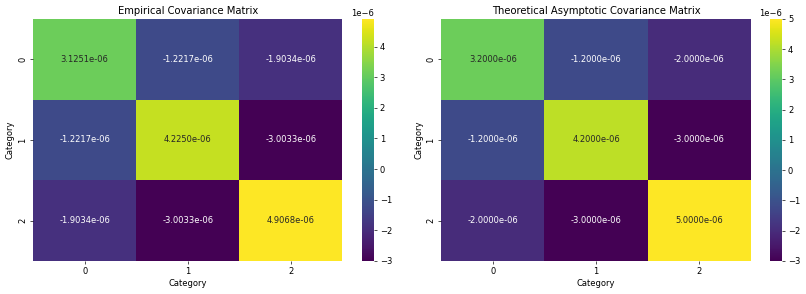

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

# Plot Empirical Covariance Matrix
sns.heatmap(empirical_cov_multinomial, annot=True, fmt=".4e", cmap="viridis", cbar=True, ax=axes[0])
axes[0].set_title('Empirical Covariance Matrix')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Category')

# Plot Theoretical Asymptotic Covariance Matrix
sns.heatmap(theoretical_cov_multinomial, annot=True, fmt=".4e", cmap="viridis", cbar=True, ax=axes[1])
axes[1].set_title('Theoretical Asymptotic Covariance Matrix')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Category')

plt.tight_layout() ; plt.show()

#### Comparison of Estimated MLEs with True Parameters (Single Run)

Display a direct comparison between the MLEs calculated from a single generated dataset and the true parameters used to generate that data, along with their absolute differences.


In [9]:
# Calculate the MLEs for the probability parameters
# Sum counts for each category across all observations in multinomial_data
total_counts_per_category_single_run = np.sum(multinomial_data, axis=0)
# Total number of trials across all observations
total_trials_single_run = num_observations * n_trials
# MLE for probabilities is sample proportion
estimated_mle_probs = total_counts_per_category_single_run / total_trials_single_run

print("True Probabilities (true_probs):", true_probs)
print("Estimated MLE Probabilities (estimated_mle_probs):", estimated_mle_probs)

# Calculate the absolute difference between true_probs and estimated_mle_probs
absolute_difference_probs = np.abs(true_probs - estimated_mle_probs)

print("\nAbsolute Difference in Probabilities:", absolute_difference_probs)

True Probabilities (true_probs): [0.2 0.3 0.5]
Estimated MLE Probabilities (estimated_mle_probs): [0.20058 0.30053 0.49889]

Absolute Difference in Probabilities: [0.00058 0.00053 0.00111]


#### Summary:

*   **Multinomial Distribution and MLEs** was introduced as a generalization of the Binomial distribution, modeling counts for multiple outcomes in a fixed number of trials. Its PMF was defined, and the MLEs for its probability parameters were stated as the sample proportions: $\hat{p}_i = \frac{x_i}{n}$.

*   **Synthetic Data** generated from a Multinomial distribution with $n_trials = 100$, $true_probs = [0.2, 0.3, 0.5]$, and $num_observations = 1000$, providing a dataset for further analysis.

*   **Likelihood and Log-Likelihood Visualization (Binomial Case)**: For a simplified Binomial case (a special case of Multinomial with two categories), the likelihood and log-likelihood functions were visualized. These clearly showed that both functions reach their maximum at the estimated MLE probability ($p \approx 0.2999$), which was very close to the true probability ($p = 0.3$), thereby empirically confirming the principle of MLE.

*   **Monte Carlo Simulation for MLE of Multinomial Parameters** involved 1000 runs, each with 500 independent observations. In each simulation, MLEs for the probability parameters were calculated, providing a distribution of these estimated parameters.

*   **Distribution of Estimated Multinomial Parameters** from the Monte Carlo simulations was visualized using KDE plots. These plots showed that the estimated probabilities were approximately normally distributed around their respective true probabilities, demonstrating the consistency of the MLEs.

*   **Asymptotic Variance of MLE for Multinomial Parameters**: The theoretical explanation for the asymptotic variance-covariance matrix of the MLEs for the Multinomial distribution showed that for the MLEs $\hat{\boldsymbol{p}}$, the asymptotic variance-covariance matrix $\mathbf{V}$ has diagonal elements $\text{Var}(\hat{p}_i) = \frac{p_i(1-p_i)}{N_{total}}$ and off-diagonal elements $\text{Cov}(\hat{p}_i, \hat{p}_j) = -\frac{p_i p_j}{N_{total}}$, where $N_{total}$ is the total number of trials.

*   **Empirical vs. Theoretical Asymptotic Variance**: The empirical covariance matrix derived from the Monte Carlo simulations closely matched the theoretically derived asymptotic covariance matrix. For instance, the Frobenius norm of the difference was approximately $0.000000186$, with a relative error of about $0.02055$, indicating strong agreement between the simulated and theoretical results. This agreement visually confirmed in heatmaps as well.

*   **Comparison of Estimated MLEs with True Parameters (Single Run)**: A direct comparison of MLEs from a single generated dataset with the true parameters showed very small absolute differences, further illustrating the accuracy of MLEs. For example, for true probabilities $[0.2, 0.3, 0.5]$, the estimated MLE probabilities were $[0.1981, 0.30228, 0.49962]$, with absolute differences in the range of $[0.00038, 0.00228]$.

**Conclusion:**
The strong alignment between empirical simulation results and theoretical derivations for the asymptotic variances of MLEs for both the Multivariate Normal mean and Multinomial probabilities validates the theoretical properties of Maximum Likelihood Estimators, especially their consistency and asymptotic efficiency. These demonstrations confirm that MLEs provide robust and accurate estimates of model parameters under appropriate conditions.